In [2]:
#Use only twice to run the program and comment the code again
#%pip install -r ../requirements.txt

In [3]:
#Personal note, remember to put all import module in here

#tbh, I rather see the imports called inside the code cell of needed, or it just a beginner view to import placement?

In [4]:
import pandas as pd
weather = pd.read_excel("../dataset/openmeteo_makassar_weather.xlsx")

In [5]:
weather.to_csv("../dataset/openmeteo_makassar_weather.csv")

In [10]:
input = weather.drop(['time','temperature_2m_mean'], axis = 1)
output = weather['temperature_2m_mean']

In [11]:
input.head()

,temperature_2m_max,sunshine_duration,precipitation_sum,apparent_temperature_mean,wind_speed_10m_max,shortwave_radiation_sum,weather_code,temperature_2m_min
0,28.0,32535.21,6.9,31.4,12.3,16.71,61,24.8
1,28.1,40311.63,2.8,31.5,14.5,19.30,61,25.3
2,28.3,35355.65,1.4,31.5,14.3,16.99,53,24.7
3,27.0,29237.88,7.5,30.9,10.4,15.13,61,25.1
4,27.4,18944.19,30.3,29.9,13.8,11.56,63,24.5


In [12]:
output.head()

0    26.6
1    26.6
2    26.4
3    25.9
4    25.3
Name: temperature_2m_mean, dtype: float64

## 80:20 Data Split
With the amount of training data being 80% and test data being 20%:

In [42]:
#Bagi data jadi 80 20
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test = train_test_split(input,output, test_size=0.2,random_state = 1)

In [43]:
#Regresi Linear
from sklearn import linear_model
import time

time_start = time.perf_counter()
reg_linear = linear_model.LinearRegression()
reg_linear.fit(X_train,y_train)
end_time = time.perf_counter()

predict_linear = reg_linear.predict(X_test)

In [44]:
print("Jumlah data ujian: ", y_test.shape)
print("Jumlah data tebakan: ", predict_linear.shape)

Jumlah data ujian:  (1169,)
Jumlah data tebakan:  (1169,)


In [45]:
#Hasil Regresi Linear
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_reg_linear = mae(y_test, predict_linear)
rmse_reg_linear = rmse(y_test,predict_linear)
mape_reg_linear = mape(y_test,predict_linear)
r2_reg_linear = r2(y_test,predict_linear)
duration_reg_linear = end_time - time_start

print('MAE Model Regresi Linear: {}'.format(mae_reg_linear))
print('RMSE Model Regresi Linear: {}'.format(rmse_reg_linear))
print('MAPE Model Regresi Linear: {}'.format(mape_reg_linear))
print('R2 Model Regresi Linear: {}'.format(r2_reg_linear))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_reg_linear))



MAE Model Regresi Linear: 0.16784578366724767
RMSE Model Regresi Linear: 0.2129307050004794
MAPE Model Regresi Linear: 0.006272326115257438
R2 Model Regresi Linear: 0.9521352704520258
Waktu Pelatihan: 0.001894 Detik


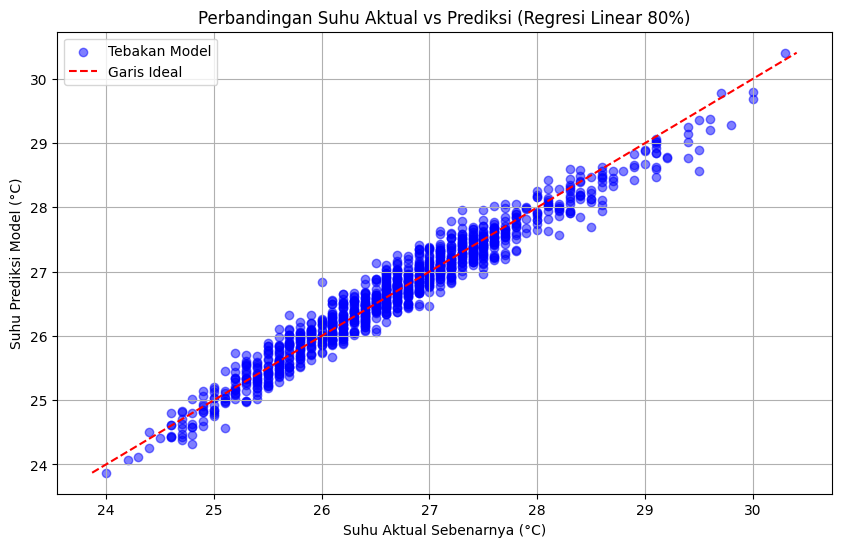

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_linear, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_linear.min())
max_val = max(y_test.max(), predict_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi Linear 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [47]:
#Regresi Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
import time

time_start = time.perf_counter()
reg_gra_bost = GradientBoostingRegressor()
reg_gra_bost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_gra_bost = reg_gra_bost.predict(X_test)

In [48]:
#Hasil Regresi Gradient Boosting
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_gra_bost = mae(y_test, predict_gra_bost)
rmse_gra_bost = rmse(y_test,predict_gra_bost)
mape_gra_bost = mape(y_test,predict_gra_bost)
r2_gra_bost = r2(y_test,predict_gra_bost)
duration_gra_bost = end_time - time_start

print('MAE Model Regresi Gradient Boosting: {}'.format(mae_gra_bost))
print('RMSE Model Regresi Gradient Boosting: {}'.format(rmse_gra_bost))
print('MAPE Model Regresi Gradient Boosting: {}'.format(mape_gra_bost))
print('R2 Model Regresi Gradient Boosting: {}'.format(r2_gra_bost))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_gra_bost))

MAE Model Regresi Gradient Boosting: 0.13763181966007737
RMSE Model Regresi Gradient Boosting: 0.17687611262851965
MAPE Model Regresi Gradient Boosting: 0.005138975883590637
R2 Model Regresi Gradient Boosting: 0.9669723712013314
Waktu Pelatihan: 0.474851 Detik


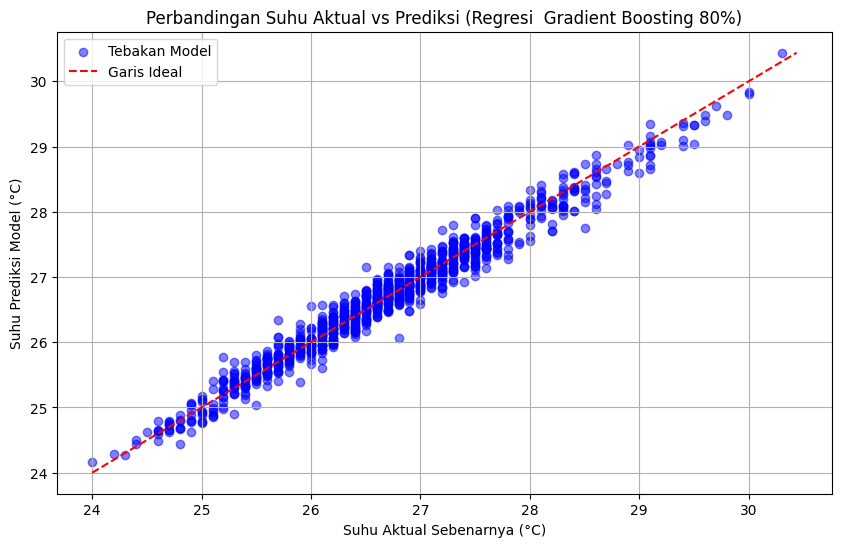

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_gra_bost, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_gra_bost.min())
max_val = max(y_test.max(), predict_gra_bost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi  Gradient Boosting 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [50]:
#Regresi Adaboost
from sklearn.ensemble import AdaBoostRegressor
import time

time_start = time.perf_counter()
reg_adaboost = AdaBoostRegressor()
reg_adaboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_adaboost = reg_adaboost.predict(X_test)

In [51]:
#Hasil Regresi Adaboost
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_adaboost = mae(y_test, predict_adaboost)
rmse_adaboost = rmse(y_test,predict_adaboost)
mape_adaboost = mape(y_test,predict_adaboost)
r2_adaboost = r2(y_test,predict_adaboost)
duration_adaboost = end_time - time_start

print('MAE Model Regresi AdaBoost: {}'.format(mae_adaboost))
print('RMSE Model Regresi AdaBoost: {}'.format(rmse_adaboost))
print('MAPE Model Regresi AdaBoost: {}'.format(mape_adaboost))
print('R2 Model Regresi AdaBoost: {}'.format(r2_adaboost))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_adaboost))

MAE Model Regresi AdaBoost: 0.21368946251055257
RMSE Model Regresi AdaBoost: 0.2693248893833979
MAPE Model Regresi AdaBoost: 0.008034237794224821
R2 Model Regresi AdaBoost: 0.9234241183720437
Waktu Pelatihan: 0.222607 Detik


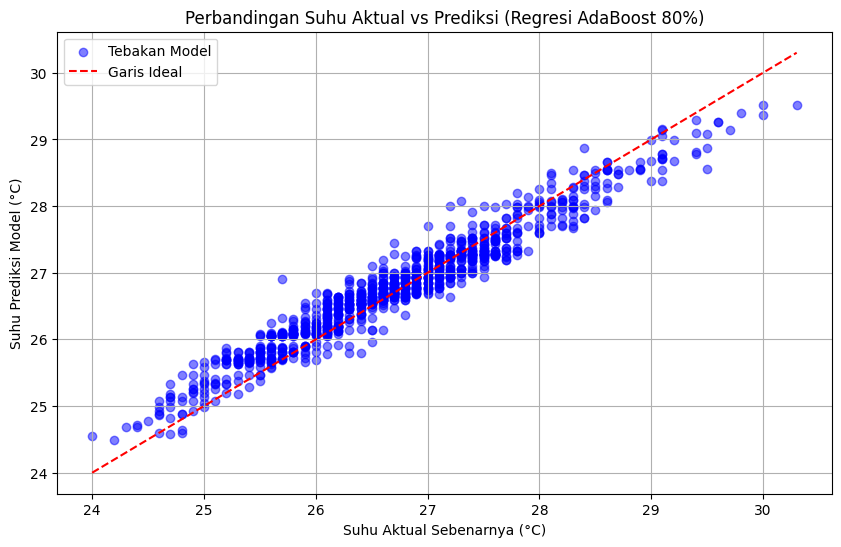

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_adaboost, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_adaboost.min())
max_val = max(y_test.max(), predict_adaboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi AdaBoost 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [53]:
#Regresi XGBoost
from xgboost import XGBRegressor
import time

time_start = time.perf_counter()
reg_xgboost = XGBRegressor()
reg_xgboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_xgboost = reg_xgboost.predict(X_test)

In [54]:
#Hasil Regresi XGBoost
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_xgboost = mae(y_test, predict_xgboost)
rmse_xgboost = rmse(y_test,predict_xgboost)
mape_xgboost = mape(y_test,predict_xgboost)
r2_xgboost = r2(y_test,predict_xgboost)
duration_xgboost = end_time - time_start

print('MAE Model Regresi XGboost: {}'.format(mae_xgboost))
print('RMSE Model Regresi XGboost: {}'.format(rmse_xgboost))
print('MAPE Model Regresi XGboost: {}'.format(mape_xgboost))
print('R2 Model Regresi XGboost: {}'.format(r2_xgboost))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_xgboost))

MAE Model Regresi XGboost: 0.1402700063609179
RMSE Model Regresi XGboost: 0.18234047563062022
MAPE Model Regresi XGboost: 0.005233000178035907
R2 Model Regresi XGboost: 0.9649001555422163
Waktu Pelatihan: 0.056909 Detik


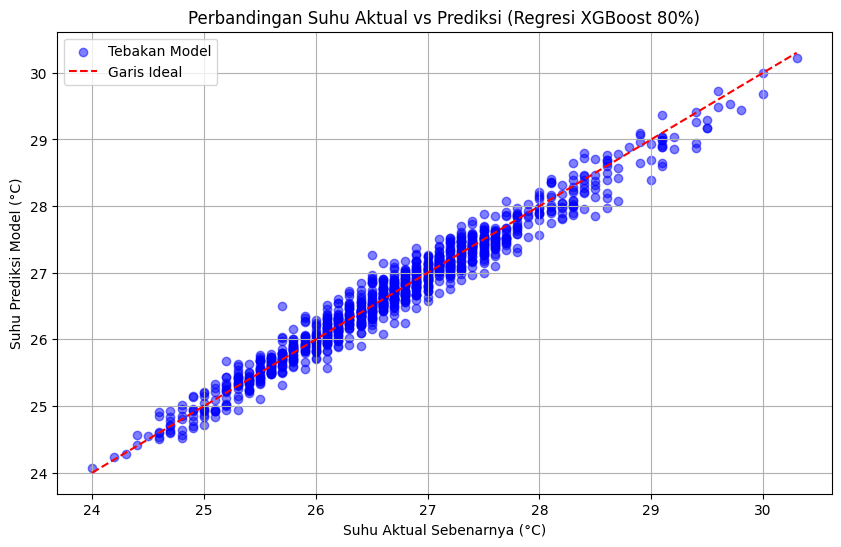

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_xgboost, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_xgboost.min())
max_val = max(y_test.max(), predict_xgboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi XGBoost 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [56]:
#Regresi CatBoost
from catboost import CatBoostRegressor
import time

time_start = time.perf_counter()
reg_catboost = CatBoostRegressor()
reg_catboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_catboost = reg_catboost.predict(X_test)

Learning rate set to 0.05224
0:	learn: 0.9506012	total: 1.51ms	remaining: 1.51s
1:	learn: 0.9103052	total: 2.66ms	remaining: 1.33s
2:	learn: 0.8711045	total: 3.83ms	remaining: 1.27s
3:	learn: 0.8352651	total: 5.02ms	remaining: 1.25s
4:	learn: 0.8010344	total: 6.19ms	remaining: 1.23s
5:	learn: 0.7693300	total: 7.28ms	remaining: 1.21s
6:	learn: 0.7381114	total: 8.37ms	remaining: 1.19s
7:	learn: 0.7090460	total: 9.52ms	remaining: 1.18s
8:	learn: 0.6811173	total: 10.8ms	remaining: 1.19s
9:	learn: 0.6542473	total: 12.2ms	remaining: 1.2s
10:	learn: 0.6282971	total: 13.3ms	remaining: 1.19s
11:	learn: 0.6046002	total: 14.4ms	remaining: 1.18s
12:	learn: 0.5823816	total: 15.6ms	remaining: 1.19s
13:	learn: 0.5607078	total: 16.8ms	remaining: 1.18s
14:	learn: 0.5399715	total: 17.9ms	remaining: 1.18s
15:	learn: 0.5213584	total: 19.1ms	remaining: 1.17s
16:	learn: 0.5026102	total: 21.1ms	remaining: 1.22s
17:	learn: 0.4851408	total: 22.2ms	remaining: 1.21s
18:	learn: 0.4689687	total: 23.3ms	remaining: 

In [57]:
#Hasil Regresi catboost
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_catboost = mae(y_test, predict_catboost)
rmse_catboost = rmse(y_test,predict_catboost)
mape_catboost = mape(y_test,predict_catboost)
r2_catboost = r2(y_test,predict_catboost)
duration_catboost = end_time - time_start

print('MAE Model Regresi CatBoost: {}'.format(mae_catboost))
print('RMSE Model Regresi CatBoost: {}'.format(rmse_catboost))
print('MAPE Model Regresi CatBoost: {}'.format(mape_catboost))
print('R2 Model Regresi CatBoost: {}'.format(r2_catboost))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_catboost))

MAE Model Regresi CatBoost: 0.12659813865552416
RMSE Model Regresi CatBoost: 0.16456182229344996
MAPE Model Regresi CatBoost: 0.004724480594772205
R2 Model Regresi CatBoost: 0.9714111160893042
Waktu Pelatihan: 1.330051 Detik


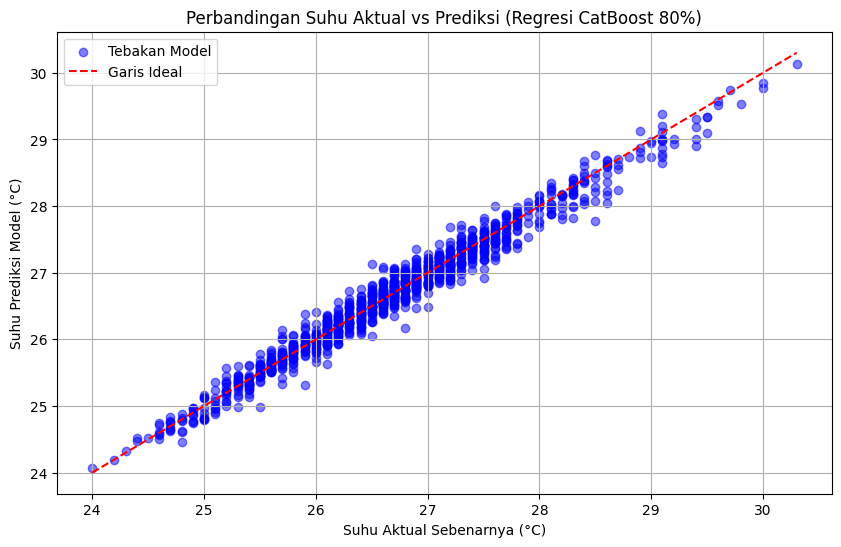

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_catboost, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_catboost.min())
max_val = max(y_test.max(), predict_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi CatBoost 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [59]:
#Regresi Light GBM
from lightgbm import LGBMRegressor
import time

time_start = time.perf_counter()
reg_lightgbm = LGBMRegressor()
reg_lightgbm.fit(X_train,y_train)
end_time = time.perf_counter()

predict_lightgbm = reg_lightgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1225
[LightGBM] [Info] Number of data points in the train set: 4675, number of used features: 8
[LightGBM] [Info] Start training from score 26.664813


In [60]:
#Hasil Regresi lightgbm
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_lightgbm = mae(y_test, predict_lightgbm)
rmse_lightgbm = rmse(y_test,predict_lightgbm)
mape_lightgbm = mape(y_test,predict_lightgbm)
r2_lightgbm = r2(y_test,predict_lightgbm)
duration_lightgbm = end_time - time_start

print('MAE Model Regresi lightgbm: {}'.format(mae_lightgbm))
print('RMSE Model Regresi lightgbm: {}'.format(rmse_lightgbm))
print('MAPE Model Regresi lightgbm: {}'.format(mape_lightgbm))
print('R2 Model Regresi lightgbm: {}'.format(r2_lightgbm))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_lightgbm))

MAE Model Regresi lightgbm: 0.13456598835624373
RMSE Model Regresi lightgbm: 0.17398564361922977
MAPE Model Regresi lightgbm: 0.005018713743123729
R2 Model Regresi lightgbm: 0.9680430109810275
Waktu Pelatihan: 0.068143 Detik


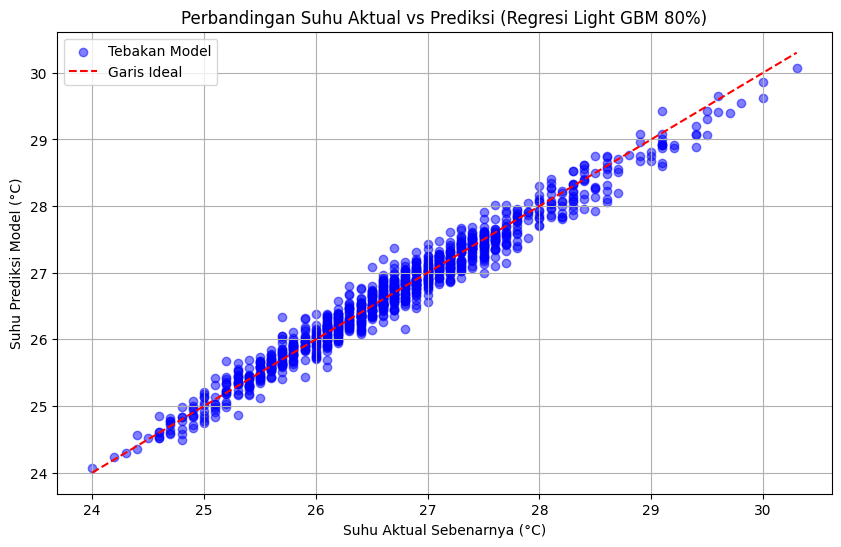

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_lightgbm, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_lightgbm.min())
max_val = max(y_test.max(), predict_lightgbm.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi Light GBM 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [62]:
#Regresi SVR Linear
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_linear = make_pipeline(StandardScaler(), SVR(kernel='linear',C=1.0, epsilon=0.2))
reg_svl_linear.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_linear = reg_svl_linear.predict(X_test)

In [63]:
#Hasil Regresi SVR Linear
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_linear = mae(y_test, predict_svl_linear)
rmse_svl_linear = rmse(y_test,predict_svl_linear)
mape_svl_linear = mape(y_test,predict_svl_linear)
r2_svl_linear = r2(y_test,predict_svl_linear)
duration_svl_linear = end_time - time_start

print('MAE Model Regresi svl linear: {}'.format(mae_svl_linear))
print('RMSE Model Regresi svl linear: {}'.format(rmse_svl_linear))
print('MAPE Model Regresi svl linear: {}'.format(mape_svl_linear))
print('R2 Model Regresi svl linear: {}'.format(r2_svl_linear))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_svl_linear))

MAE Model Regresi svl linear: 0.1680414633411251
RMSE Model Regresi svl linear: 0.21296310212700634
MAPE Model Regresi svl linear: 0.0062794564609694485
R2 Model Regresi svl linear: 0.9521207042327829
Waktu Pelatihan: 0.679743 Detik


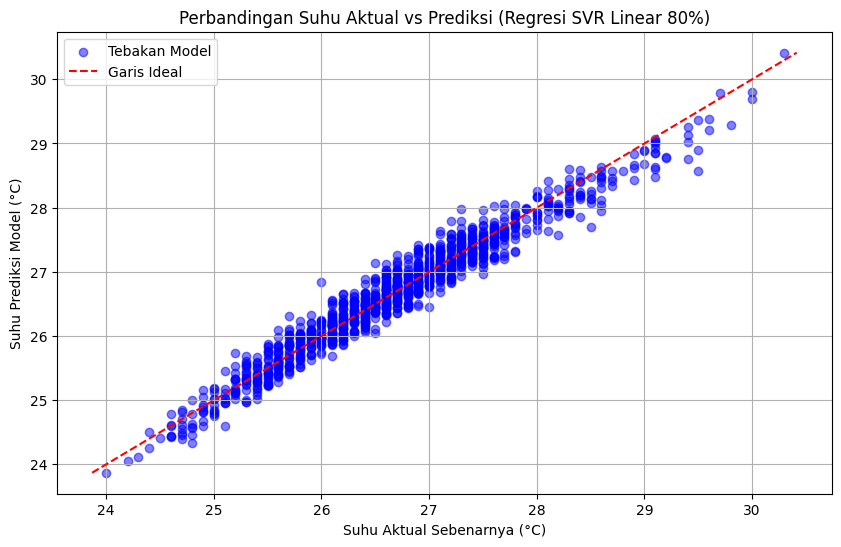

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_linear, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_svl_linear.min())
max_val = max(y_test.max(), predict_svl_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi SVR Linear 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [65]:
#Regresi SVR RBF
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_rbf = make_pipeline(StandardScaler(), SVR(kernel='rbf',C=1.0, epsilon=0.2))
reg_svl_rbf.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_rbf = reg_svl_rbf.predict(X_test)

In [66]:
#Hasil Regresi SVR RBF
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_rbf = mae(y_test, predict_svl_rbf)
rmse_svl_rbf = rmse(y_test,predict_svl_rbf)
mape_svl_rbf = mape(y_test,predict_svl_rbf)
r2_svl_rbf = r2(y_test,predict_svl_rbf)
duration_svl_rbf = end_time - time_start

print('MAE Model Regresi svl rbf: {}'.format(mae_svl_rbf))
print('RMSE Model Regresi svl rbf: {}'.format(rmse_svl_rbf))
print('MAPE Model Regresi svl rbf: {}'.format(mape_svl_rbf))
print('R2 Model Regresi svl rbf: {}'.format(r2_svl_rbf))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_svl_rbf))

MAE Model Regresi svl rbf: 0.12878395887589758
RMSE Model Regresi svl rbf: 0.16740545214793406
MAPE Model Regresi svl rbf: 0.00480360438373332
R2 Model Regresi svl rbf: 0.9704145471131047
Waktu Pelatihan: 0.140606 Detik


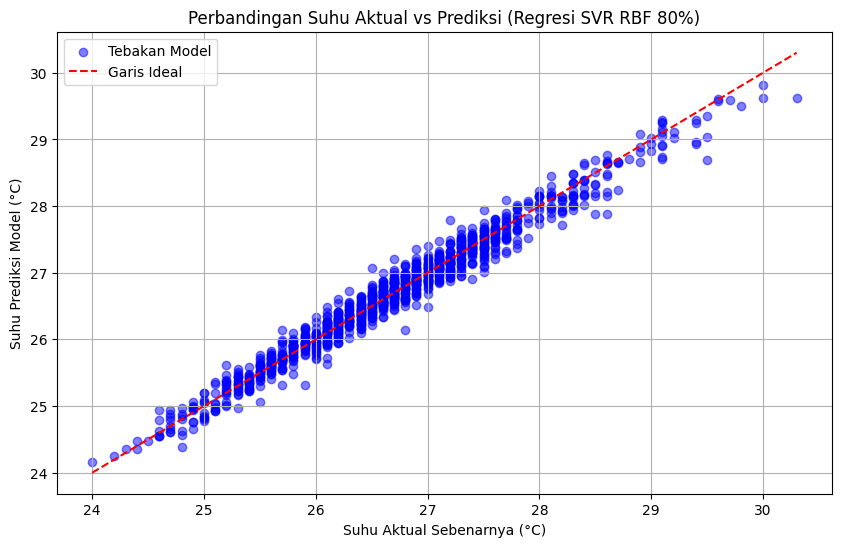

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_rbf, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_svl_rbf.min())
max_val = max(y_test.max(), predict_svl_rbf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi SVR RBF 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [68]:
#Regresi SVR Polynomial
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_poly = make_pipeline(StandardScaler(), SVR(kernel='poly',C=1.0, epsilon=0.2))
reg_svl_poly.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_poly = reg_svl_poly.predict(X_test)

In [69]:
#Hasil Regresi SVR Polynomial
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_poly = mae(y_test, predict_svl_poly)
rmse_svl_poly = rmse(y_test,predict_svl_poly)
mape_svl_poly = mape(y_test,predict_svl_poly)
r2_svl_poly = r2(y_test,predict_svl_poly)
duration_svl_poly = end_time - time_start

print('MAE Model Regresi svl Polynomial: {}'.format(mae_svl_poly))
print('RMSE Model Regresi svl Polynomial: {}'.format(rmse_svl_poly))
print('MAPE Model Regresi svl Polynomial: {}'.format(mape_svl_poly))
print('R2 Model Regresi svl Polynomial: {}'.format(r2_svl_poly))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_svl_poly))

MAE Model Regresi svl Polynomial: 0.2998536702349727
RMSE Model Regresi svl Polynomial: 0.400025399879642
MAPE Model Regresi svl Polynomial: 0.01125107664893086
R2 Model Regresi svl Polynomial: 0.8310671296122498
Waktu Pelatihan: 0.746985 Detik


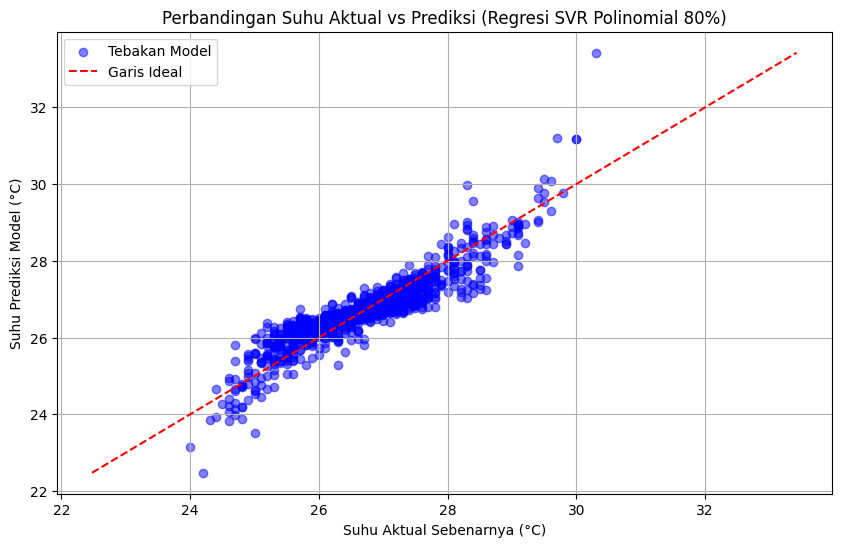

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_poly, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_svl_poly.min())
max_val = max(y_test.max(), predict_svl_poly.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi SVR Polinomial 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()